PART A: DATA PREPARATION

In [77]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans

In [78]:
file_path = "StudentPerformanceFactors.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
)

In [79]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [81]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [82]:
print("=== Categorical Columns ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{df[col].value_counts()}")

=== Categorical Columns ===

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near   

In [83]:
# Check for missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# Check for duplicates
print("\n=== Duplicate Rows ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

=== Missing Values ===
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

=== Duplicate Rows ===
Number of duplicate rows: 0


In [84]:
# Fill Missing Values with mode for categorical columns
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [85]:
# Check for missing values after cleaning
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

=== Missing Values ===
No missing values found.


In [86]:
# Identify all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columns to check for outliers:", num_cols)

Columns to check for outliers: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


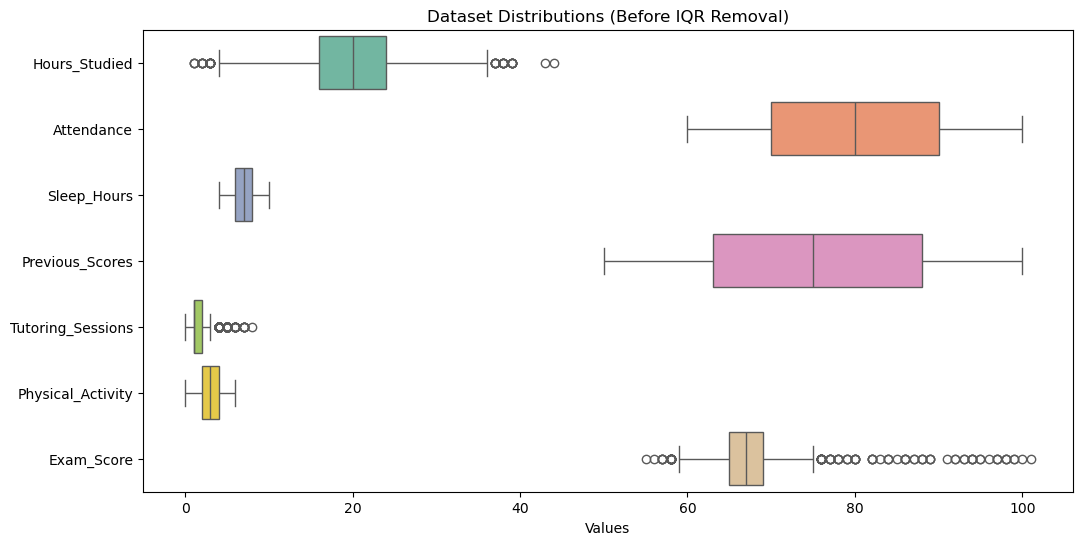

In [87]:
# Visualize the dataset before removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2")
plt.title("Dataset Distributions (Before IQR Removal)")
plt.xlabel("Values")
plt.show()

In [88]:
# Apply selective IQR method to remove outliers
df_cleaned = df.copy()

for col in num_cols:
    multiplier = 1.5

    # Use higher multiplier to only filter extreme outliers for Exam_Score
    if col == "Exam_Score":
        multiplier = 2.0  

    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (multiplier * IQR)
    upper_bound = Q3 + (multiplier * IQR)
    
    df_cleaned = df_cleaned[
        (df_cleaned[col] >= lower_bound) & 
        (df_cleaned[col] <= upper_bound)
    ]

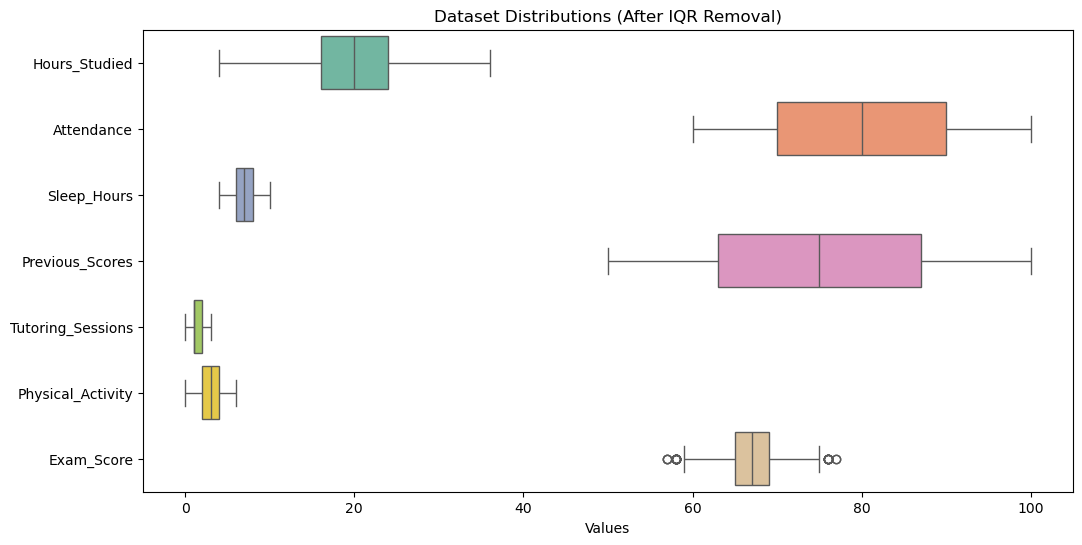

=== Outlier Removal Summary ===
Original dataset rows: 6607
Cleaned dataset rows:  6086
Total rows removed:    521


In [89]:
# Visualize the dataset after cleanup and print a summary of the outlier removal process
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[num_cols], orient="h", palette="Set2")
plt.title("Dataset Distributions (After IQR Removal)")
plt.xlabel("Values")
plt.show()

print("=== Outlier Removal Summary ===")
print(f"Original dataset rows: {df.shape[0]}")
print(f"Cleaned dataset rows:  {df_cleaned.shape[0]}")
print(f"Total rows removed:    {df.shape[0] - df_cleaned.shape[0]}")

In [90]:
# Separate target variable and features
TARGET = "Exam_Score"

# Drop target from features
features = df_cleaned.drop(columns=[TARGET])
target = df_cleaned[TARGET]

print("Target variable:", TARGET)
print("Number of features:", features.shape[1])
print("Feature columns:", features.columns.tolist())

Target variable: Exam_Score
Number of features: 19
Feature columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [91]:
# Identify categorical columns
cat_cols = features.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Apply One-Hot Encoding
features_encoded = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# Apply Standard Scaling
scaler = StandardScaler()
features_scaled_array = scaler.fit_transform(features_encoded)

# Convert back to DataFrame
features_final = pd.DataFrame(
    features_scaled_array, 
    columns=features_encoded.columns
)

print("New shape after encoding:", features_final.shape)
features_final.head()

Categorical columns to encode: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
New shape after encoding: (6086, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.515668,0.351411,-0.023491,-0.146183,-1.312599,0.038907,2.000205,-1.022938,-0.498408,-1.005272,...,0.806638,0.660344,-0.804697,1.227432,-0.339808,0.995410,-0.497894,-0.659575,0.820864,0.856970
1,-0.172530,-1.382566,0.657311,-1.121546,0.719834,1.009362,2.000205,-1.022938,-0.498408,0.994756,...,0.806638,0.660344,-0.804697,-0.814709,-0.339808,-1.004611,-0.497894,1.516128,-1.218229,-1.166902
2,0.687717,1.565195,-0.023491,1.107855,0.719834,1.009362,-0.499949,0.977576,-0.498408,0.994756,...,0.806638,0.660344,1.242704,-0.814709,-0.339808,-1.004611,2.008460,-0.659575,0.820864,0.856970
3,1.547965,0.784905,0.657311,1.595536,-0.296382,1.009362,2.000205,-1.022938,-0.498408,0.994756,...,0.806638,0.660344,-0.804697,-0.814709,-0.339808,0.995410,-0.497894,1.516128,-1.218229,0.856970
4,-0.172530,1.045002,-0.704294,-0.703533,1.736050,1.009362,-0.499949,0.977576,-0.498408,0.994756,...,-1.239714,0.660344,1.242704,-0.814709,-0.339808,-1.004611,-0.497894,-0.659575,0.820864,-1.166902


In [92]:
# For Supervised Learning (Regression)
X_regression = features_final.copy()
Y_regression = target.copy()

# For Unsupervised Learning (Clustering)
X_clustering = features_final.copy() 

In [93]:
data_desc = """
DATA DESCRIPTION:
The dataset is synthetically generated (sourced from Kaggle: lainguyn123/student-performance-factors). 
It contains 20 academic and socio-economic attributes across 6,607 student records. 
The target variable for regression is Exam_Score (numerical). Key features include 
study habits (Hours_Studied, Tutoring_Sessions), environmental factors 
(Internet_Access, Family_Income, Teacher_Quality), and personal metrics 
(Motivation_Level, Physical_Activity).

PREPROCESSING STEPS:
1. Missing Values: 235 missing entries in 'Teacher_Quality', 'Parental_Education_Level', 
   and 'Distance_from_Home' were imputed using the Mode (most frequent value).
2. Duplicate Check: Verified dataset for identical records; no duplicates were found.
3. Categorical Encoding: Nominal and ordinal variables were transformed using 
   One-Hot Encoding, expanding the feature space to allow the model to capture 
   non-linear relationships between categorical states.
4. Outlier Removal (Selective IQR): A standard 1.5x IQR was applied to features, 
   while a wider 2.0x IQR was applied specifically to 'Exam_Score'. This preserved 
   genuine high/low achieving "signal" while filtering out extreme synthetic noise.
5. Scaling: StandardScaler was applied to all numerical features to normalize 
   distributions, which is critical for the K-Means clustering in Part C.
"""

print(data_desc)
print("-" * 50)
print(f"Target Variable:      Exam_Score")
# num_features list will now likely be longer due to One-Hot Encoding
print(f"Total Features:       {len(features_final.columns)} (Expanded via One-Hot Encoding)")
print("-" * 50)
print(f"Original Row Count:   6,607")
print(f"Final Row Count:      {df_cleaned.shape[0]} (Retained: {round(df_cleaned.shape[0] / 6607 * 100, 2)}%)")
print(f"Rows Removed:         {6607 - df_cleaned.shape[0]}")


DATA DESCRIPTION:
The dataset is synthetically generated (sourced from Kaggle: lainguyn123/student-performance-factors). 
It contains 20 academic and socio-economic attributes across 6,607 student records. 
The target variable for regression is Exam_Score (numerical). Key features include 
study habits (Hours_Studied, Tutoring_Sessions), environmental factors 
(Internet_Access, Family_Income, Teacher_Quality), and personal metrics 
(Motivation_Level, Physical_Activity).

PREPROCESSING STEPS:
1. Missing Values: 235 missing entries in 'Teacher_Quality', 'Parental_Education_Level', 
   and 'Distance_from_Home' were imputed using the Mode (most frequent value).
2. Duplicate Check: Verified dataset for identical records; no duplicates were found.
3. Categorical Encoding: Nominal and ordinal variables were transformed using 
   One-Hot Encoding, expanding the feature space to allow the model to capture 
   non-linear relationships between categorical states.
4. Outlier Removal (Selective IQ

PART B: SUPERVISED LEARNING (REGRESSION)

In [94]:
X_regression.shape, Y_regression.shape

((6086, 27), (6086,))

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_regression, Y_regression, test_size=0.2, random_state=1)

In [96]:
X_train.shape, Y_train.shape

((4868, 27), (4868,))

In [97]:
X_test.shape, Y_test.shape

((1218, 27), (1218,))

In [98]:
def evaluate_model(model):
    model.fit(X_train, Y_train)
    preds = model.predict(X_test) # Predict once to save time
    train_preds = model.predict(X_train) # Predict on training set for R^2 calculation

    print("=== Model Evaluation ===")
    print("Mean Absolute Error:", mean_absolute_error(Y_test, preds))
    print("Mean Squared Error:", mean_squared_error(Y_test, preds))
    print("R^2 Score:", r2_score(Y_test, preds))

    print("\n=== Training Set R^2 Score ===")
    print("R^2 Score on Training Set:", r2_score(Y_train, train_preds))

In [99]:
linear_model = LinearRegression()
evaluate_model(linear_model)
print("\nCoefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

=== Model Evaluation ===
Mean Absolute Error: 0.2775904805897903
Mean Squared Error: 0.1107590805684899
R^2 Score: 0.9902024936149344

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.9900748444603901

Coefficients: [ 1.73269574e+00  2.30562801e+00  2.24967896e-02  7.06413744e-01
  4.91791311e-01  2.46986283e-01 -7.95346900e-01 -5.01772008e-01
 -7.99377642e-01 -4.87029502e-01  2.48353738e-01 -4.64174093e-01
 -2.53254709e-01  2.67936761e-01 -4.81138732e-01 -2.38928636e-01
 -3.00374520e-01 -2.45835662e-01  7.82541351e-04  2.45323740e-01
  4.91150732e-01 -3.05385856e-01 -2.42322406e-01  2.10575104e-01
  2.32747780e-01  4.93802375e-01 -3.08732045e-04]
Intercept: 66.96389655922579


In [100]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=0.001)
evaluate_model(ridge_model)

=== Model Evaluation ===
Mean Absolute Error: 0.2775904854533303
Mean Squared Error: 0.11075909379556012
R^2 Score: 0.9902024924448967

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.99007484446032


In [101]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.001)
evaluate_model(lasso_model)

=== Model Evaluation ===
Mean Absolute Error: 0.27747569059685984
Mean Squared Error: 0.11066198878562682
R^2 Score: 0.9902110821420119

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.990069896722946


In [102]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(alpha=0.001)
evaluate_model(elastic_model)

=== Model Evaluation ===
Mean Absolute Error: 0.2775589558162169
Mean Squared Error: 0.11075051993222015
R^2 Score: 0.9902032508701236

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.9900720400156531


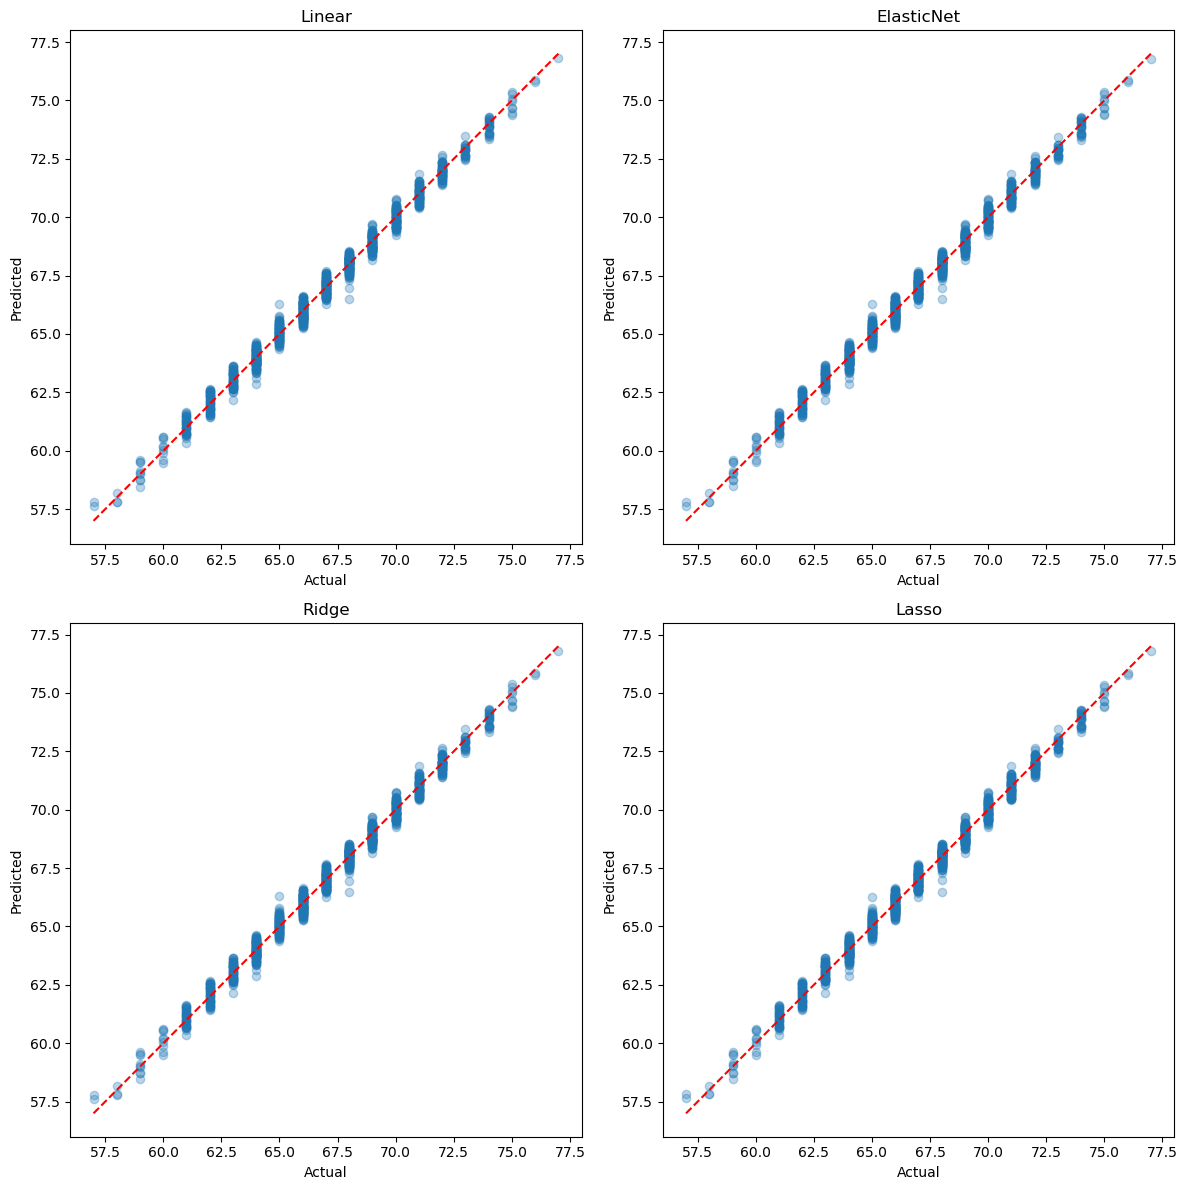

In [103]:
import matplotlib.pyplot as plt

models = {
    'Linear': linear_model,
    'ElasticNet': elastic_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten() 

for ax, (name, model) in zip(axes, models.items()):
    Y_pred = model.predict(X_test)
    ax.scatter(Y_test, Y_pred, alpha=0.3)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # perfect prediction line
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)

plt.tight_layout()
plt.show()

PART C: UNSUPERVISED LEARNING (K-MEANS CLUSTERING)

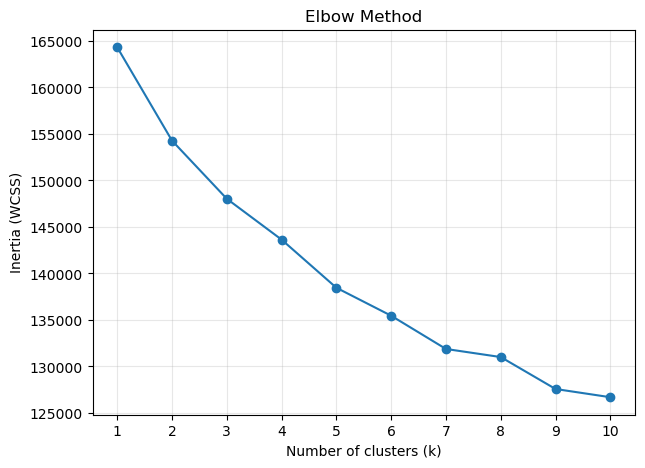

In [104]:
ks = range(1, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clustering)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(list(ks))
plt.grid(alpha=0.3)
plt.show()

In [105]:
curvature = np.diff(inertias, 2)
optimal_k = list(ks)[np.argmin(curvature) + 1]
print("Suggested optimal k:", optimal_k)

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_clustering)

print("Cluster counts:", np.bincount(cluster_labels))

Suggested optimal k: 8
Cluster counts: [ 568  850  601  682  570  675  966 1174]


In [106]:
from IPython.display import display

df_clustered = df_cleaned.copy()
df_clustered["Cluster"] = cluster_labels

print("--- First 5 Students and their Clusters ---")
# display() renders a beautiful HTML table in notebooks
display(df_clustered.head())

print("\n--- Cluster Distribution ---")
# Convert the value_counts Series into a clean DataFrame before displaying
cluster_counts = df_clustered["Cluster"].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster ID', 'Number of Students']

display(cluster_counts)

--- First 5 Students and their Clusters ---


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Cluster
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,3
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,7
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,7
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,1



--- Cluster Distribution ---


,Cluster ID,Number of Students
0,0,568
1,1,850
2,2,601
3,3,682
4,4,570
5,5,675
6,6,966
7,7,1174


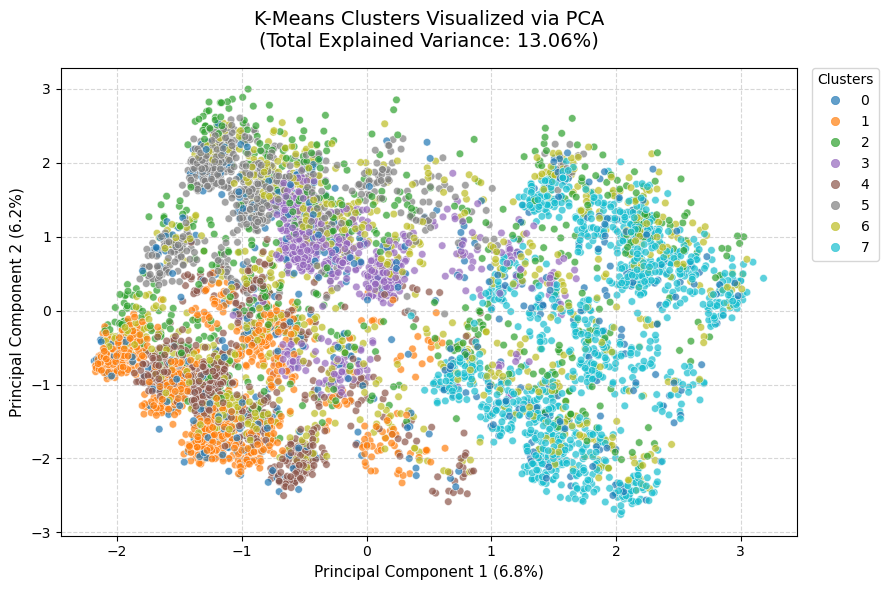

In [107]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering)
var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=cluster_labels, 
                     cmap="tab10", 
                     s=30, 
                     alpha=0.7, 
                     edgecolors='w', 
                     linewidth=0.5)

plt.legend(*scatter.legend_elements(),
           loc="upper left", 
           title="Clusters", 
           bbox_to_anchor=(1.02, 1), 
           borderaxespad=0)
plt.title(f"K-Means Clusters Visualized via PCA\n(Total Explained Variance: {sum(var_ratio)*100:.2f}%)", 
          fontsize=14, pad=15)
plt.xlabel(f"Principal Component 1 ({var_ratio[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({var_ratio[1]*100:.1f}%)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(rect=[0, 0, 0.9, 1]) 
plt.show()

In [108]:
numerical_cols = df_clustered.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_clustered.select_dtypes(exclude=['number']).columns.tolist()

if 'Cluster' in numerical_cols: numerical_cols.remove('Cluster')

num_summary = df_clustered.groupby('Cluster')[numerical_cols].mean()
cat_summary = df_clustered.groupby('Cluster')[categorical_cols].agg(lambda x: x.mode()[0])
master_profile = pd.concat([num_summary, cat_summary], axis=1)
master_profile = master_profile.sort_values(by='Exam_Score', ascending=False)

print("--- Complete Master Cluster Profiles ---")
display(master_profile.T)

--- Complete Master Cluster Profiles ---


Cluster,1,4,3,7,5,2,6,0
Hours_Studied,20.32,19.724561,20.230205,19.973595,19.682963,19.883527,20.224638,19.723592
Attendance,80.203529,80.207018,79.387097,79.683986,79.939259,80.311148,80.492754,79.211268
Sleep_Hours,6.958824,6.938596,7.060117,7.07155,7.013333,6.993344,7.091097,7.109155
Previous_Scores,74.74,76.284211,74.639296,74.979557,75.77037,76.096506,73.930642,75.371479
Tutoring_Sessions,1.276471,1.364912,1.29912,1.273424,1.241481,1.257903,1.322981,1.31162
Physical_Activity,2.995294,2.984211,2.926686,2.97615,2.915556,3.014975,2.904762,2.977113
Exam_Score,68.003529,67.547368,67.395894,67.136286,66.936296,66.439268,66.1853,65.889085
Parental_Involvement,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium
Access_to_Resources,Medium,Medium,Medium,Medium,Medium,Medium,Low,Medium
Extracurricular_Activities,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes


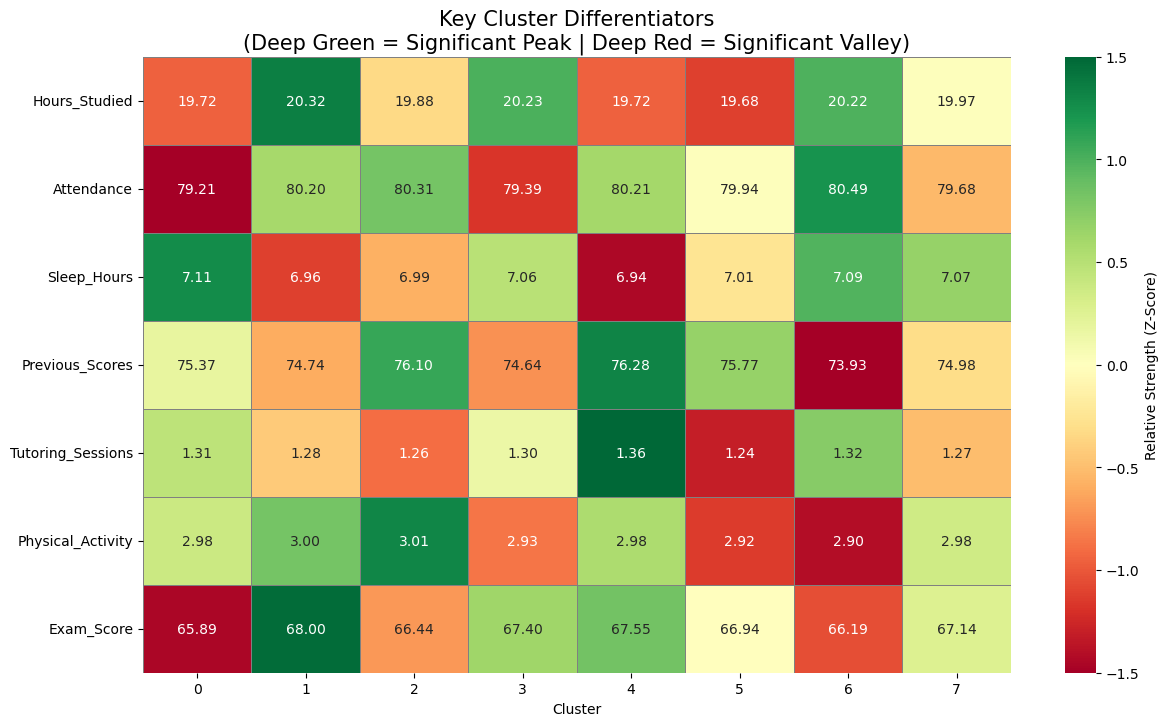

In [109]:
num_summary = df_clustered.groupby('Cluster')[numerical_cols].mean()
z_scores = num_summary.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(z_scores.T, 
            annot=num_summary.T, 
            fmt='.2f', 
            cmap='RdYlGn', 
            center=0,
            vmin=-1.5, vmax=1.5, 
            cbar_kws={'label': 'Relative Strength (Z-Score)'},
            linewidths=0.5,
            linecolor='gray')

plt.title('Key Cluster Differentiators\n(Deep Green = Significant Peak | Deep Red = Significant Valley)', fontsize=15)
plt.show()